In [5]:
!pip install -q torch torchvision albumentations opencv-python scikit-learn pandas numpy matplotlib seaborn tqdm

# ***DATA Prep***

In [12]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_DIR = "/content/temp_dataset/plantvillage dataset/color"
SPLIT_DIR = "data/splits"

os.makedirs(SPLIT_DIR, exist_ok=True)

data = []

class_names = sorted(os.listdir(DATA_DIR))

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        data.append({
            "image_path": img_path,
            "label_index": idx,
            "class_name": class_name
        })

df = pd.DataFrame(data)

# First split: 85% train+val, 15% test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["label_index"],
    random_state=42
)

# Second split: 70% train, 15% val
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,  # 0.1765 × 0.85 ≈ 0.15
    stratify=train_val_df["label_index"],
    random_state=42
)

# Save
train_df.to_csv(os.path.join(SPLIT_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(SPLIT_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(SPLIT_DIR, "test.csv"), index=False)

print("Splits created successfully.")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Splits created successfully.
Train: 38011
Val: 8148
Test: 8146


In [13]:
!ls data/splits

test.csv  train.csv  val.csv


## ***Training***

In [14]:
!python src/train.py

Using device: cuda
GPU: Tesla T4
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/content/plant_disease_detection/plant_disease_detection/src/augmentation.py:17: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 134MB/s]

===== PHASE 1: Training classifier head only =====

Phase 1 - Epoch 1/5
100% 1188/1188 [04:59<00:00,  3.97it/s]
100% 255/255 [00:35<00:00,  7.11it/s]
Train Acc: 0.7519 | Val Acc: 0.9743

Phase 1 - Epoch 2/5
100% 1188/1188 [05:12<00:00,  3.80it/s]
100% 255/255 [00:41<00:00,  6.15it/s]
Train Acc: 0.8494 | Val Acc: 0

# ***Load BEST Model***

In [15]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from src.model import build_resnet50
from src.dataset import PlantDiseaseDataset
from src.augmentation import get_val_transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
model = build_resnet50()
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/plant_assets/best_model.pth"
))
model.to(DEVICE)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# ***Load Test Dataset***

In [16]:
test_dataset = PlantDiseaseDataset(
    "data/splits/test.csv",
    transform=get_val_transforms()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# ***Run Inference on Test Set***

In [17]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = np.mean(all_preds == all_labels)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.992020623618954


# ***Full Classification Report***

In [18]:
report = classification_report(
    all_labels,
    all_preds,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           0     0.9792    1.0000    0.9895        94
           1     1.0000    1.0000    1.0000        93
           2     1.0000    1.0000    1.0000        41
           3     1.0000    0.9960    0.9980       247
           4     1.0000    1.0000    1.0000       225
           5     1.0000    0.9937    0.9968       158
           6     1.0000    1.0000    1.0000       128
           7     0.8824    0.9740    0.9259        77
           8     1.0000    1.0000    1.0000       179
           9     0.9857    0.9324    0.9583       148
          10     1.0000    1.0000    1.0000       174
          11     0.9944    1.0000    0.9972       177
          12     1.0000    0.9952    0.9976       207
          13     1.0000    1.0000    1.0000       161
          14     0.9844    1.0000    0.9921        63
          15     1.0000    0.9988    0.9994       826
          16     0.9971    1.0000    0.9986       345
          17     1.0000    

# ***Confusion Matrix***

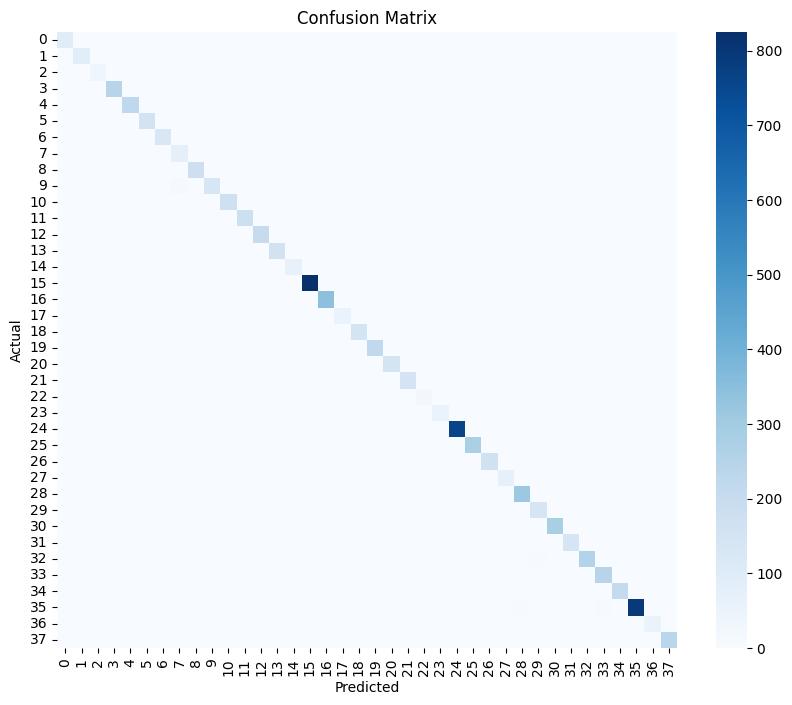

In [21]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()